shape of target_joint_positions_cache: (50, 12)
shape of target_ee_cache: (50, 12)


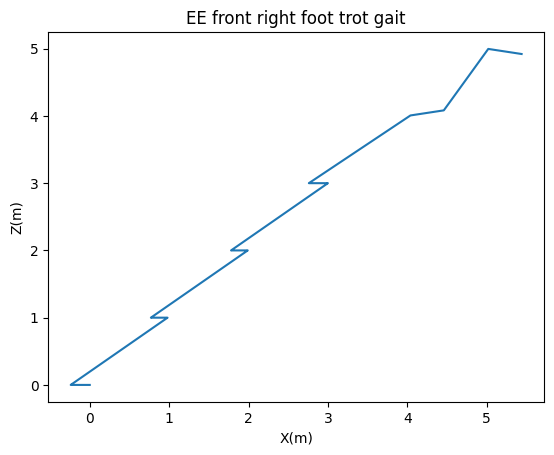

In [6]:
import numpy as np
import scipy
np.set_printoptions(precision=3, suppress=True)
from matplotlib import pyplot as plt

def rotation_x(angle):
    return np.array([
        [1, 0, 0, 0],
        [0, np.cos(angle), -np.sin(angle), 0],
        [0, np.sin(angle), np.cos(angle), 0],
        [0, 0, 0, 1]
    ])

def rotation_y(angle):
    return np.array([
        [np.cos(angle), 0, np.sin(angle), 0],
        [0, 1, 0, 0],
        [-np.sin(angle), 0, np.cos(angle), 0],
        [0, 0, 0, 1]
    ])

def rotation_z(angle):
    return np.array([
        [np.cos(angle), -np.sin(angle), 0, 0],
        [np.sin(angle), np.cos(angle), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

def translation(x, y, z):
    return np.array([
        [1, 0, 0, x],
        [0, 1, 0, y],
        [0, 0, 1, z],
        [0, 0, 0, 1]
    ])

class InverseKinematics():

    def __init__(self):
        self.joint_positions = None
        self.joint_velocities = None
        self.target_joint_positions = None
        self.counter = 0

        # Trotting gate positions
        ################################################################################################
        # TODO: Implement the trotting gait
        ################################################################################################
        touch_down_position = np.array([0.5,0,-0.14])
        stand_position_1 = np.array([0.25,0,-0.14])
        stand_position_2 = np.array([0,0,-0.14])
        stand_position_3 = np.array([-0.25,0,-0.14])
        liftoff_position = np.array([-0.5,0,-0.14])
        mid_swing_position = np.array([0,0,-0.05])
        
        ## trotting
        # TODO: Implement each leg’s trajectory in the trotting gait.
        rf_ee_offset = np.array([0.06, -0.09, 0])
        rf_ee_triangle_positions = np.array([
            ################################################################################################
            # TODO: Implement the trotting gait
            ################################################################################################
            touch_down_position,
            stand_position_1,
            stand_position_2,
            stand_position_3,
            liftoff_position,
            mid_swing_position
        ]) + rf_ee_offset
        
        lf_ee_offset = np.array([0.06, 0.09, 0])
        lf_ee_triangle_positions = np.array([
            stand_position_3,
            liftoff_position,
            mid_swing_position,
            touch_down_position,
            stand_position_1,
            stand_position_2
        ]) + lf_ee_offset
        
        rb_ee_offset = np.array([-0.11, -0.09, 0])
        rb_ee_triangle_positions = np.array([
            stand_position_3,
            liftoff_position,
            mid_swing_position,
            touch_down_position,
            stand_position_1,
            stand_position_2
        ]) + rb_ee_offset
        
        lb_ee_offset = np.array([-0.11, 0.09, 0])
        lb_ee_triangle_positions = np.array([
            touch_down_position,
            stand_position_1,
            stand_position_2,
            stand_position_3,
            liftoff_position,
            mid_swing_position

        ]) + lb_ee_offset


        self.ee_triangle_positions = [rf_ee_triangle_positions, lf_ee_triangle_positions, rb_ee_triangle_positions, lb_ee_triangle_positions]
        self.fk_functions = [self.fr_leg_fk, self.fl_leg_fk, self.br_leg_fk, self.bl_leg_fk]

        ####### TODO: Uncomment when you want to generate the cache #######
        self.target_joint_positions_cache, self.target_ee_cache = self.cache_target_joint_positions()
        print(f'shape of target_joint_positions_cache: {self.target_joint_positions_cache.shape}')
        print(f'shape of target_ee_cache: {self.target_ee_cache.shape}')


    def fr_leg_fk(self, theta):
        T_RF_0_1 = translation(0.07500, -0.08350, 0) @ rotation_x(1.57080) @ rotation_z(theta[0])
        T_RF_1_2 = rotation_y(-1.57080) @ rotation_z(theta[1])
        T_RF_2_3 = translation(0, -0.04940, 0.06850) @ rotation_y(1.57080) @ rotation_z(theta[2])
        T_RF_3_ee = translation(0.06231, -0.06216, 0.01800)
        T_RF_0_ee = T_RF_0_1 @ T_RF_1_2 @ T_RF_2_3 @ T_RF_3_ee
        return T_RF_0_ee[:3, 3]

    def fl_leg_fk(self, theta):
        T_LF_0_1 = translation(0.07500, 0.08350, 0) @ rotation_x(1.57080) @ rotation_z(-theta[0])
        T_LF_1_2 = rotation_y(-1.57080) @ rotation_z(theta[1])
        T_LF_2_3 = translation(0, -0.04940, 0.06850) @ rotation_y(1.57080) @ rotation_z(-theta[2])
        T_LF_3_ee = translation(0.06231, -0.06216, -0.01800)
        T_LF_0_ee = T_LF_0_1 @ T_LF_1_2 @ T_LF_2_3 @ T_LF_3_ee
        return T_LF_0_ee[:3, 3]

    def br_leg_fk(self, theta):
        T_RB_0_1 = translation(-0.07500, -0.07250, 0) @ rotation_x(1.57080) @ rotation_z(theta[0])
        T_RB_1_2 = rotation_y(-1.57080) @ rotation_z(theta[1])
        T_RB_2_3 = translation(0, -0.04940, 0.06850) @ rotation_y(1.57080) @ rotation_z(theta[2])
        T_RB_3_ee = translation(0.06231, -0.06216, 0.01800)
        T_RB_0_ee = T_RB_0_1 @ T_RB_1_2 @ T_RB_2_3 @ T_RB_3_ee
        return T_RB_0_ee[:3, 3]

    def bl_leg_fk(self, theta):
        T_LB_0_1 = translation(-0.07500, 0.07250, 0) @ rotation_x(1.57080) @ rotation_z(-theta[0])
        T_LB_1_2 = rotation_y(-1.57080) @ rotation_z(theta[1])
        T_LB_2_3 = translation(0, -0.04940, 0.06850) @ rotation_y(1.57080) @ rotation_z(-theta[2])
        T_LB_3_ee = translation(0.06231, -0.06216, -0.01800)
        T_LB_0_ee = T_LB_0_1 @ T_LB_1_2 @ T_LB_2_3 @ T_LB_3_ee
        return T_LB_0_ee[:3, 3]

    def forward_kinematics(self, theta):
        return np.concatenate([self.fk_functions[i](theta[3*i: 3*i+3]) for i in range(4)])
        
    def get_error_leg(self, theta, desired_position):
        scalar_difference = np.linalg.norm(self.leg_forward_kinematics(theta) - desired_position)
        return scalar_difference

    def inverse_kinematics_single_leg(self, target_ee, leg_index, initial_guess=[0, 0, 0]):
        self.leg_forward_kinematics = self.fk_functions[leg_index]
        res = scipy.optimize.minimize(self.get_error_leg, initial_guess, args=(target_ee) )
        return res.x

    def interpolate_triangle(self, t, leg_index):
        ################################################################################################
        # TODO: implement interpolation for all 4 legs here
        ################################################################################################
        current = (t * 6)
        prev = (int)(np.floor(current)) % 6
        next = (int)(np.ceil(current)) % 6

        diff = current - prev

        lowest_to_next = self.ee_triangle_positions[leg_index][next] - self.ee_triangle_positions[leg_index][prev]
        
        interp_position = prev + lowest_to_next * diff

        return interp_position

    def cache_target_joint_positions(self):
        # Calculate and store the target joint positions for a cycle and all 4 legs
        target_joint_positions_cache = []
        target_ee_cache = []
        for leg_index in range(4):
            target_joint_positions_cache.append([])
            target_ee_cache.append([])
            target_joint_positions = [0] * 3
            for t in np.arange(0, 1, 0.02):
                target_ee = self.interpolate_triangle(t, leg_index)
                target_joint_positions = self.inverse_kinematics_single_leg(target_ee, leg_index, initial_guess=target_joint_positions)
                target_joint_positions_cache[leg_index].append(target_joint_positions)
                target_ee_cache[leg_index].append(target_ee)

        # (4, 50, 3) -> (50, 12)
        target_joint_positions_cache = np.concatenate(target_joint_positions_cache, axis=1)
        target_ee_cache = np.concatenate(target_ee_cache, axis=1)
        
        return target_joint_positions_cache, target_ee_cache

    def get_target_joint_positions(self):
        target_joint_positions = self.target_joint_positions_cache[self.counter]
        target_ee = self.target_ee_cache[self.counter]
        self.counter += 1
        if self.counter >= self.target_joint_positions_cache.shape[0]:
            self.counter = 0
        return target_ee, target_joint_positions




def main():

    # Create an instance of the IK class
    inverse_kinematics = InverseKinematics()

    # Test IK solver on right front leg
    target_ee_list = [
        [0.11, -0.09, -0.14],
        [0.10, -0.09, -0.14],
        [0.09, -0.09, -0.14],
        [0.08, -0.09, -0.14],
        [0.07, -0.09, -0.14],
        [0.06, -0.09, -0.14],
        [0.05, -0.09, -0.14],
        [0.04, -0.09, -0.14],
        [0.03, -0.09, -0.14],
        [0.02, -0.09, -0.14],
        [0.01, -0.09, -0.14],
    ]

    inverse_kinematics.leg_forward_kinematics = inverse_kinematics.fk_functions[0]
    result_ee_list = []
    result_thetas = []
    for target_ee in target_ee_list:
        theta = inverse_kinematics.inverse_kinematics_single_leg(target_ee, leg_index=0, initial_guess=[0, 0, 0])
        result_ee = inverse_kinematics.leg_forward_kinematics(theta)
        result_ee_list.append(result_ee)
        result_thetas.append(theta)

    result_thetas = np.array(result_thetas)
    # # Plot the EE results
    # if len(result_ee_list) > 0:
    #     plt.plot(np.array(target_ee_list)[:,0],'k')
    #     plt.plot(np.array(result_ee_list)[:,0],'ro')
    #     plt.plot(result_thetas[:,0],'c')
    #     plt.plot(result_thetas[:,1],'b')
    #     plt.plot(result_thetas[:,2],'g')
    #     plt.xlabel('Step')
    #     plt.ylabel('X (m)')
    #     plt.legend(['Target EE Position','Result EE Position', 'Joint 0', 'Joint 1', 'Joint 2'])
    #     plt.title('End Effector X position')
    #     plt.show()

    # Plot the cached trot gait path for one foot.
    if len(inverse_kinematics.target_ee_cache):
        x_list = []
        z_list = []
        for position in inverse_kinematics.target_ee_cache:
            x_list.append(position[0])
            z_list.append(position[2])
        plt.xlabel('X(m)')
        plt.ylabel('Z(m)')
        plt.title('EE front right foot trot gait')
        plt.plot(x_list, z_list)
        plt.show()



if __name__ == '__main__':
    main()
